# Product Ratings & Customer Preference Analysis

**Business Context**:

Neat Furniture Store, an online furniture retailer, seeks to better understand customer purchasing behavior, product preferences, and satisfaction levels across its product categories, brands, and services. With increasing competition in the e-commerce space, the business requires data-driven insights into pricing, delivery performance, and value-added services (such as assembly) to enhance customer experience and optimize product strategy.

**Objectives**:

- Analyze customer purchase behavior and product demand across categories, subcategories, and brands 
- Evaluate the impact of pricing, shipping, and assembly services on total order value and customer satisfaction 
- Identify top-performing and underperforming products based on ratings and sales patterns 
- Assess delivery performance and payment methods to uncover drivers of customer experience and retention


In [1]:
import numpy as np, pandas as pd
import seaborn as sns, matplotlib.pyplot as plt
sns.set(color_codes=True)
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.float_format', lambda x: '%.5f' % x)

## Sanity Checks

#### Loading and displaying the first and last few rows of the dataset

In [2]:
df = pd.read_csv("C:/Users/HP PC/Downloads/online_furniture_retailer.csv")
df.head()

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27000,45.63000,86.82000,323.72000,11,3.20000
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87000,52.65000,183.07000,938.59000,10,4.50000
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41000,96.79000,0.00000,492.20000,2,NaN
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59000,0.00000,0.00000,602.59000,9,NaN
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36000,69.23000,41.53000,1893.12000,13,1.30000


In [3]:
df.tail()

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
1933,Bedroom,Chest of Drawers,Overstock,Delivered,False,PayPal,84537,1474,2020.28000,95.02000,0.00000,2115.30000,9,2.90000
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03000,0.00000,91.56000,1020.59000,9,4.40000
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73000,0.00000,58.77000,785.50000,11,NaN
1936,Living Room,Armchair,Wayfair,In Transit,True,Google Pay,42701,1541,2109.30000,NaN,NaN,2374.30000,3,NaN
1937,Kitchen,Kitchen Cabinet,West Elm,Pending,False,Cash on Delivery,69827,1828,550.84000,0.00000,0.00000,550.84000,10,1.10000


- The `product_category` column contains the category or type of product ordered by the customer
- The `product_subcategory` column contains the actual product ordered by the customer
- The `brand` column contains the brand of the product ordered by the customer
- The `delivery_status` column contains the status of delivery of the product ordered
- The `assembly_service_requested` column states whether or not a customer included a product assembly request/service along with their order
- The `payment_method` column contains the mode of payment used by the customer in making their order
- The `order_id` and `customer_id` columns contain the distinct identification of orders placed and the customers for placed them
- All other columns contain several important numerical information
- Each row corresponds to a unique product order
- There appears to be some missing data in the `shipping_cost`, `assembly_cost` and `customer_rating` columns
- Everything else appears to be okay with the dataset

#### Checking the shape of the dataset

In [4]:
df.shape

(1938, 14)

1938 rows and 14 columns make up the dataset

#### Checking the datatypes

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1938 entries, 0 to 1937
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_category            1938 non-null   object 
 1   product_subcategory         1938 non-null   object 
 2   brand                       1842 non-null   object 
 3   delivery_status             1938 non-null   object 
 4   assembly_service_requested  1938 non-null   bool   
 5   payment_method              1938 non-null   object 
 6   order_id                    1938 non-null   int64  
 7   customer_id                 1938 non-null   int64  
 8   product_price               1938 non-null   float64
 9   shipping_cost               1880 non-null   float64
 10  assembly_cost               1900 non-null   float64
 11  total_amount                1938 non-null   float64
 12  delivery_window_days        1938 non-null   int64  
 13  customer_rating             1658 

- In addition to the 3 columns identified earlier, `brand` also contains missing data. All 4 columns will require further investigation later
- There are 6 categorical and 8 numerical attributes in the dataset
- The `order_id` and `customer_id` columns are saved as 'integer' datatypes, but they should be in object format. We will convert the 2 columns accordingly 

In [6]:
df['order_id'] = df['order_id'].astype('object')
df['customer_id'] = df['customer_id'].astype('object')

df.dtypes

product_category               object
product_subcategory            object
brand                          object
delivery_status                object
assembly_service_requested       bool
payment_method                 object
order_id                       object
customer_id                    object
product_price                 float64
shipping_cost                 float64
assembly_cost                 float64
total_amount                  float64
delivery_window_days            int64
customer_rating               float64
dtype: object

The conversion was done successfully. There are now 8 categorical and 6 numerical attributes in the dataset

#### Checking the statistical summary

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,1938.00000,1155.93003,658.49091,81.43000,609.24250,1076.23000,1628.55000,2979.56000
shipping_cost,1880.00000,69.62225,47.55500,0.00000,32.58500,74.05500,107.73500,150.00000
assembly_cost,1900.00000,62.69814,82.55260,0.00000,0.00000,26.28500,106.11500,299.35000
total_amount,1938.00000,1288.39001,669.22865,146.93000,722.70750,1224.17500,1758.50000,3093.29000
delivery_window_days,1938.00000,7.52838,3.98700,1.00000,4.00000,8.00000,11.00000,14.00000
customer_rating,1658.00000,3.05905,1.15208,1.00000,2.10000,3.10000,4.00000,5.00000


- The average product price is about 1156
- `product_price`, `assembly_cost` and `total_amount` have huge differences between their upper quartiles and maximum values, indicating possible outliers rightwards in the variables
- 25% of orders have 0 assembly costs
- The mean values in the `shipping_cost`, `delivery_window_days` and `customer_rating` variables are lesser than the median values, indicating left skewness in the distributions
- 50% of orders are rated above 3.1

#### Checking for missising values

In [8]:
df.isna().sum()

product_category                0
product_subcategory             0
brand                          96
delivery_status                 0
assembly_service_requested      0
payment_method                  0
order_id                        0
customer_id                     0
product_price                   0
shipping_cost                  58
assembly_cost                  38
total_amount                    0
delivery_window_days            0
customer_rating               280
dtype: int64

As observed earlier, `brand`, `shipping_cost`, `assembly_cost` and `customer_rating` have 96, 58, 38 and 280 missing data respectively. We will treat these momentarily

#### Checking for duplicates in the dataset

In [9]:
df.duplicated().sum()

0

There are no duplicates in the dataset

#### Checking the categorical levels in the dataset

In [10]:
df.columns #displaying all columns to extract the categorical ones

Index(['product_category', 'product_subcategory', 'brand', 'delivery_status',
       'assembly_service_requested', 'payment_method', 'order_id',
       'customer_id', 'product_price', 'shipping_cost', 'assembly_cost',
       'total_amount', 'delivery_window_days', 'customer_rating'],
      dtype='object')

In [11]:
cat_cols = ['product_category', 'product_subcategory', 'brand', 'delivery_status','assembly_service_requested',
            'payment_method', 'order_id', 'customer_id']

for item in cat_cols:
    print(item, '\n')
    print(df[item].value_counts())
    print(df[item].value_counts(normalize=True))
    print('-' * 45)

product_category 

Outdoor        338
Living Room    333
Office         324
Kitchen        322
Bedroom        318
Dining Room    303
Name: product_category, dtype: int64
Outdoor       0.17441
Living Room   0.17183
Office        0.16718
Kitchen       0.16615
Bedroom       0.16409
Dining Room   0.15635
Name: product_category, dtype: float64
---------------------------------------------
product_subcategory 

Bar Cart            90
Pantry Cabinet      87
Garden Chair        80
Kitchen Cabinet     75
Office Chair        73
Dining Chair        72
Lounge Chair        71
Kitchen Island      70
Desk                70
Bookshelf           69
Outdoor Table       69
Dining Table        66
Umbrella            65
Sofa                63
Mattress            62
China Cabinet       61
Buffet              60
Computer Table      59
Ottoman             58
TV Stand            57
Dresser             55
Nightstand          53
Filing Cabinet      53
Patio Set           53
Side Table          53
Coffee Table    

- Majority of orders (338) were for Outdoor products, followed by Living Room products at 333 orders, and then Office products at 324 orders. Dining Room products were ordered the least at 303 orders
- The top 5 category of products ordered were Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet and Office Chair  
- Overstock, HomeGoods and World Market brands were ordered the most at 168, 165 and 160 orders respectively, while the bottom 3 brands ordered were Crate & Barrel, Wayfair and Target at 146, 145 and 143 respectively
- Only about 18% of all orders were delivered
- Almost equal amounts of orders either included assembly service requests (50.6%) or did not (49.4%)
- Most customers (302) paid for their orders using Credit Card. An equal proportion of them (14.8% or 287) paid using Cash on Delivery and Debit Card
- There are customers who placed more than 1 order
- Some order ids are appearing twice, we need to investigate this to be sure there is no anomaly

In [12]:
df.loc[df['order_id']==70012]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
1385,Kitchen,Bar Cart,West Elm,Failed Delivery,False,Google Pay,70012,2752,430.62000,40.83000,0.00000,471.45000,4,2.20000
1471,Bedroom,Chest of Drawers,West Elm,Rescheduled,True,Google Pay,70012,3826,412.97000,61.87000,40.71000,515.55000,5,4.90000


In [13]:
df.loc[df['order_id']==96951]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
173,Dining Room,China Cabinet,Wayfair,Rescheduled,False,PayPal,96951,2697,773.15000,122.09000,0.00000,895.24000,10,4.80000
236,Dining Room,Dining Table,HomeGoods,In Transit,False,Apple Pay,96951,3041,447.78000,77.01000,0.00000,524.79000,7,3.30000


In [14]:
df.loc[df['order_id']==17989]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
142,Dining Room,Dining Chair,Pottery Barn,Delivered,True,Credit Card,17989,6138,183.23000,39.96000,193.34000,416.53000,9,4.30000
1226,Outdoor,Garden Chair,Overstock,Cancelled,False,Apple Pay,17989,3869,1305.85000,0.00000,0.00000,1305.85000,6,NaN


In [15]:
df.loc[df['order_id']==31802]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
1422,Dining Room,Bar Stool,World Market,Rescheduled,True,Google Pay,31802,1725,1661.00000,NaN,40.63000,1789.16000,1,2.00000
1827,Kitchen,Bar Cart,HomeGoods,Failed Delivery,False,Google Pay,31802,7783,2133.47000,107.71000,0.00000,2241.18000,6,NaN


In [16]:
df.loc[df['order_id']==30644]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
951,Dining Room,China Cabinet,CB2,Cancelled,True,Bank Transfer,30644,3852,1014.79000,56.09000,75.81000,1146.69000,9,3.00000
1801,Dining Room,Dining Chair,Pottery Barn,In Transit,True,PayPal,30644,8157,671.68000,0.00000,55.84000,727.52000,6,2.70000


- Each order id is appearing for 2 different customer ids. This is a problem as each unique order id should be assigned to 1 unique customer and 1 unique customer only
- We need to understand if there is an acceptable reason for this situation, and if there isn't one, it might be a better idea to drop the rows containing such order ids to ensure reliable analysis on the data

## Univariate Analysis

In [17]:
df.describe().T #showing statistical summary just to recall the numerical columns for the univariate analysis

,count,mean,std,min,25%,50%,75%,max
product_price,1938.00000,1155.93003,658.49091,81.43000,609.24250,1076.23000,1628.55000,2979.56000
shipping_cost,1880.00000,69.62225,47.55500,0.00000,32.58500,74.05500,107.73500,150.00000
assembly_cost,1900.00000,62.69814,82.55260,0.00000,0.00000,26.28500,106.11500,299.35000
total_amount,1938.00000,1288.39001,669.22865,146.93000,722.70750,1224.17500,1758.50000,3093.29000
delivery_window_days,1938.00000,7.52838,3.98700,1.00000,4.00000,8.00000,11.00000,14.00000
customer_rating,1658.00000,3.05905,1.15208,1.00000,2.10000,3.10000,4.00000,5.00000


#### Observations on Product Price

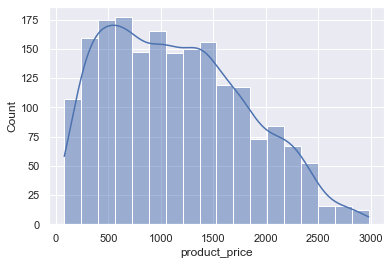

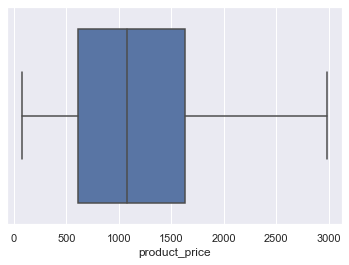

In [18]:
sns.histplot(df, x='product_price', kde=True);
plt.show()
sns.boxplot(data=df, x='product_price');
plt.show()

- The distribution of Product Price is skewed rightwards
- There are no outliers in the column
- Majority of product prices are between 81 and about 1800

#### Observations on Shipping Cost

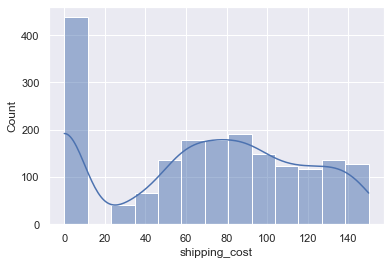

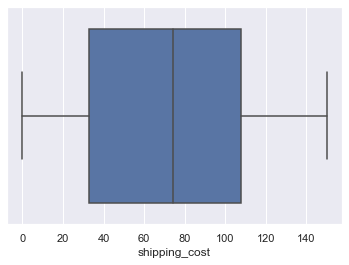

In [19]:
sns.histplot(df, x='shipping_cost', kde=True);
plt.show()
sns.boxplot(data=df, x='shipping_cost');
plt.show()

- Distribution of Shipping Cost is negatively skewed
- 75% of shipping costs are above 30

#### Observations on Assembly Cost

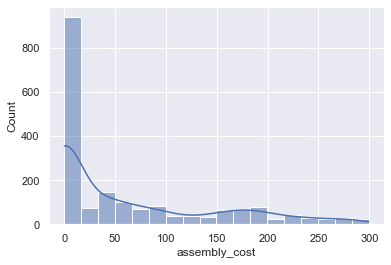

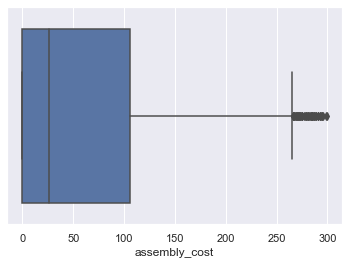

In [20]:
sns.histplot(df, x='assembly_cost', kde=True);
plt.show()
sns.boxplot(data=df, x='assembly_cost');
plt.show()

- The distribution of Assembly cost is heavily positively skewed
- The minimum value (0) is equal to the 1st quartile, meaning 25% of orders did not include assembly services
- Values after about 265 are considered outliers

In [21]:
a_cost_Q1 = df['assembly_cost'].quantile(0.25)
a_cost_Q3 = df['assembly_cost'].quantile(0.75)

a_cost_IQR = a_cost_Q3 - a_cost_Q1

In [22]:
df.loc[df['assembly_cost']>(a_cost_Q3+1.5*a_cost_IQR)].shape[0]

52

In [23]:
df.loc[df['assembly_cost']>(a_cost_Q3+1.5*a_cost_IQR)]['assembly_cost'].min()

265.68

In [24]:
df.loc[df['assembly_cost']>(a_cost_Q3+1.5*a_cost_IQR)]['assembly_cost'].max()

299.35

Assembly costs between 265.68 and 299.35 are considered outliers, and there are 52 orders with assembly costs falling within that range

#### Observations on Total Amount

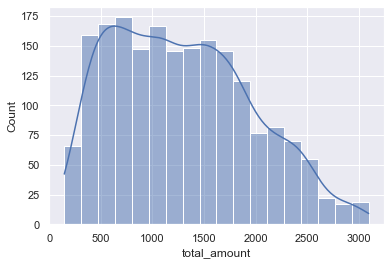

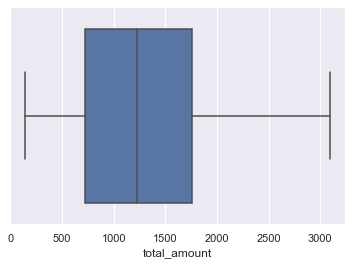

In [25]:
sns.histplot(df, x='total_amount', kde=True);
plt.show()
sns.boxplot(data=df, x='total_amount');
plt.show()

- The distribution of Total Amount is right-skewed
- 75% of values are above about 700
- There are no outliers in this column

#### Observations on Delivery Window Days

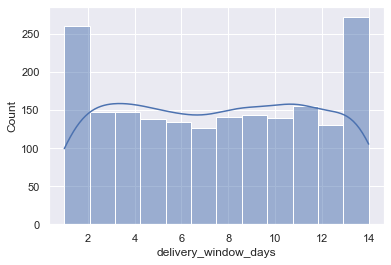

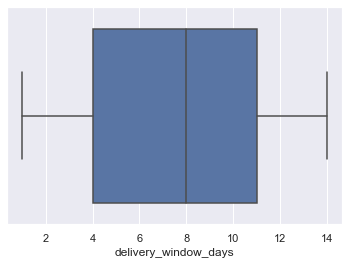

In [26]:
sns.histplot(df, x='delivery_window_days', kde=True);
plt.show()
sns.boxplot(data=df, x='delivery_window_days');
plt.show()

- The distribution of Delivery Window Days is left-skewed
- The median delivery window is 8 days
- 75% of orders are delivered within above 4 days

#### Observations on Customer Rating

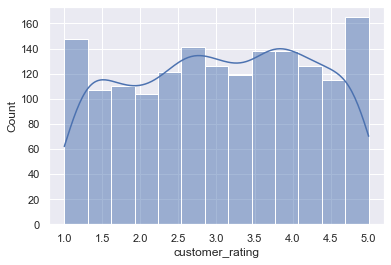

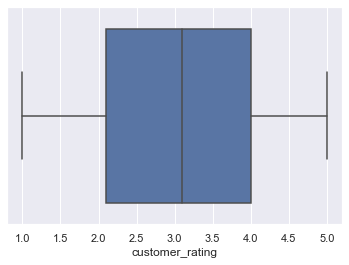

In [27]:
sns.histplot(df, x='customer_rating', kde=True);
plt.show()
sns.boxplot(data=df, x='customer_rating');
plt.show()

- The distribution of Customer Rating is left-skewed
- The ratings are reasonably distributed across values
- The median customer rating is about 3.1
- There are no outliers  in the column

#### Moving to the categorical features

In [28]:
df.head(2) #showing the first 2 row just to recall the categorical columns for the univariate analysis

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27000,45.63000,86.82000,323.72000,11,3.20000
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87000,52.65000,183.07000,938.59000,10,4.50000


#### Observations on Product Category

In [29]:
df.loc[df['shipping_cost']==0]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59000,0.00000,0.00000,602.59000,9,NaN
6,Bedroom,Mattress,IKEA,Delivered,True,Apple Pay,14165,1488,1467.44000,0.00000,184.29000,1651.73000,13,NaN
9,Living Room,Sofa,Crate & Barrel,Delivered,True,Google Pay,88907,1434,2180.54000,0.00000,239.46000,2420.00000,7,5.00000
11,Living Room,Side Table,CB2,In Transit,True,PayPal,95181,9928,2214.46000,0.00000,46.76000,2261.22000,5,3.00000
16,Bedroom,Wardrobe,CB2,Delivered,True,Bank Transfer,46421,3547,777.62000,0.00000,53.37000,830.99000,1,1.30000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1928,Office,Filing Cabinet,West Elm,Failed Delivery,False,Credit Card,59009,1920,688.63000,0.00000,0.00000,688.63000,11,3.70000
1929,Outdoor,Garden Chair,World Market,In Transit,False,Debit Card,77537,3604,1706.08000,0.00000,0.00000,1706.08000,8,1.60000
1934,Dining Room,Dining Chair,Pottery Barn,In Transit,True,Cash on Delivery,32772,4158,929.03000,0.00000,91.56000,1020.59000,9,4.40000
1935,Office,Desk,Ashley Furniture,Pending,True,Cash on Delivery,36309,1944,726.73000,0.00000,58.77000,785.50000,11,NaN


In [30]:
df.groupby(['product_category'])['shipping_cost'].mean()

product_category
Bedroom       69.53026
Dining Room   68.32461
Kitchen       68.52700
Living Room   66.74375
Office        69.45595
Outdoor       74.80828
Name: shipping_cost, dtype: float64

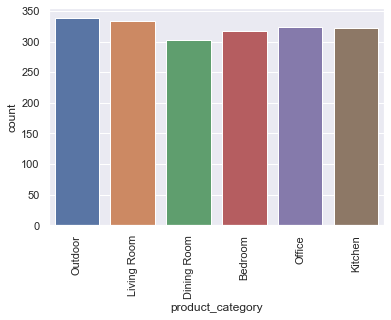

In [31]:
sns.countplot(data=df, x='product_category');
plt.xticks(rotation=90)
plt.show()

- The frequency distribution of orders across all 6 product categories are quite close
- However, Outdoor products were ordered the most and Dining Room products were least ordered

#### Observations on Product Subcategory

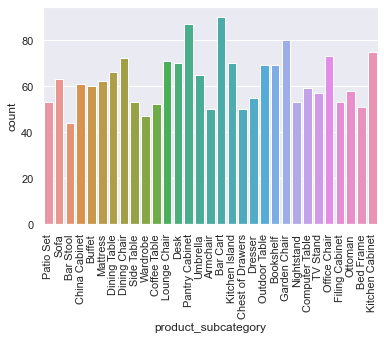

In [32]:
sns.countplot(data=df, x='product_subcategory');
plt.xticks(rotation=90)
plt.show()

- The top 6 products ordered were Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet, Office Chair and Dining Chair
- Bar Stool, Wardrobe, Armchair and Chest of Drawers (in that order) were ordered the least

- Achieving 338 and 333 orders respectively, Outdoor and Living Room are the most popular product categories among customers 
- Dining Room products were ordered the least at 303 orders
- Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet and Office Chair were the most popular product subcategories ordered by customers
- Product subcategories Bar Stool, Wardrobe, Armchair and Chest of Drawers were the least popular among customers
- 


#### Observations on Brand

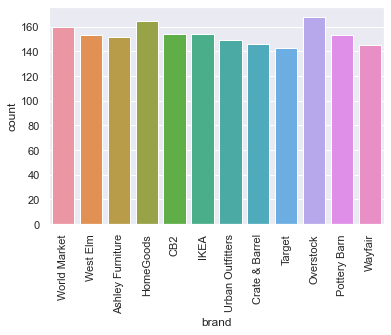

In [33]:
sns.countplot(data=df, x='brand');
plt.xticks(rotation=90)
plt.show()

- Overstock and HomeGoods were the top 2 brands ordered
- Target, Wayfair and Crate & Barrel were least ordered
- It is worth noting however, that each brand is surely not significantly far from its neighbour

- Achieving 338 and 333 orders respectively, Outdoor and Living Room are the most popular product categories among customers 
- Dining Room products were ordered the least at 303 orders
- Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet and Office Chair were the most popular product subcategories ordered by customers
- Product subcategories Bar Stool, Wardrobe, Armchair and Chest of Drawers were the least popular among customers
- Brands Overstock, HomeGoods and World Market are the top 3 patronised by customers
- Target, Wayfair and Crate & Barrel were the bottom 3 brands patronised by customised


#### Observations on Delivery Status

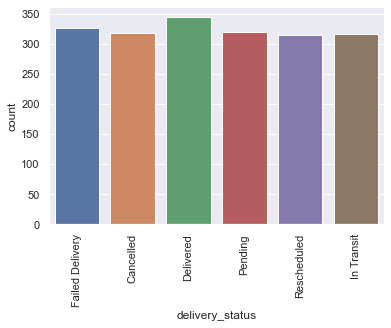

In [34]:
sns.countplot(data=df, x='delivery_status');
plt.xticks(rotation=90)
plt.show()

- Similar to Product Category, the frequency distribution of Delivery Status across orders is close
- Delivered orders are in the majority, while orders either Rescheduled or In Transit are in the minority

#### Observations on Assembly Service Requested

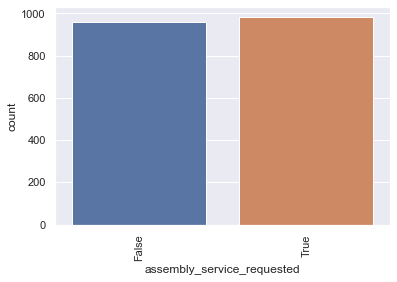

In [35]:
sns.countplot(data=df, x='assembly_service_requested');
plt.xticks(rotation=90)
plt.show()

Although by a small margin, orders including assembly service requests surpass those that don't

In [36]:
df['assembly_service_requested'].value_counts()

True     981
False    957
Name: assembly_service_requested, dtype: int64

981 orders included assembly service requests and 957 did not

#### Observations on Payment Method

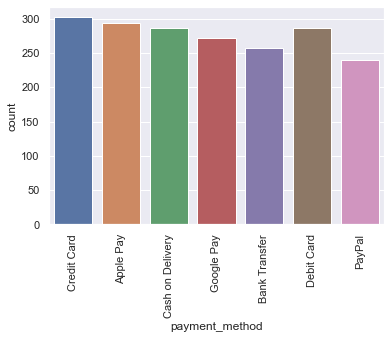

In [37]:
sns.countplot(data=df, x='payment_method');
plt.xticks(rotation=90)
plt.show()

- Most orders were paid for using Credit Card, followed by Apple Pay
- Orders paid for using PayPal are the least

#### Observations on Order ID

In [38]:
df['order_id'].nunique()

1916

There are 1916 unique order IDs

#### Observations on Customer ID

In [39]:
df['customer_id'].nunique()

1738

There are 1738 unique customers who placed 1938 orders

## Bivariate Analysis

#### Correlation by Heatmap

In [40]:
df.columns #displaying all columns to extract the numerical ones for the heatmap

Index(['product_category', 'product_subcategory', 'brand', 'delivery_status',
       'assembly_service_requested', 'payment_method', 'order_id',
       'customer_id', 'product_price', 'shipping_cost', 'assembly_cost',
       'total_amount', 'delivery_window_days', 'customer_rating'],
      dtype='object')

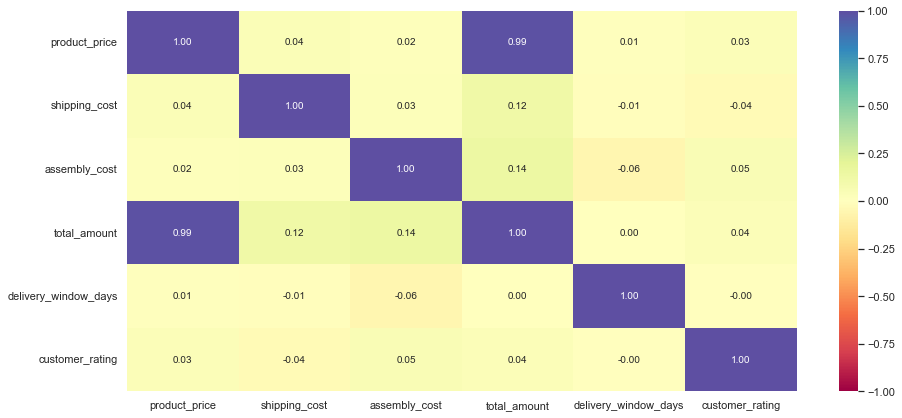

In [41]:
num_cols = ['product_price', 'shipping_cost', 'assembly_cost', 'total_amount', 'delivery_window_days', 'customer_rating']

plt.figure(figsize=(15,7))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral');
plt.show()

- `total_amount` has a strong positive correlation with `product_price` and a weak postive correlation with `shipping_cost` and `assembly_cost`. This is due to the latter 3 being added up to make the former
- All other correlation coefficients are practically 0, meaning there is no correlation between the variables

#### Scatterplots

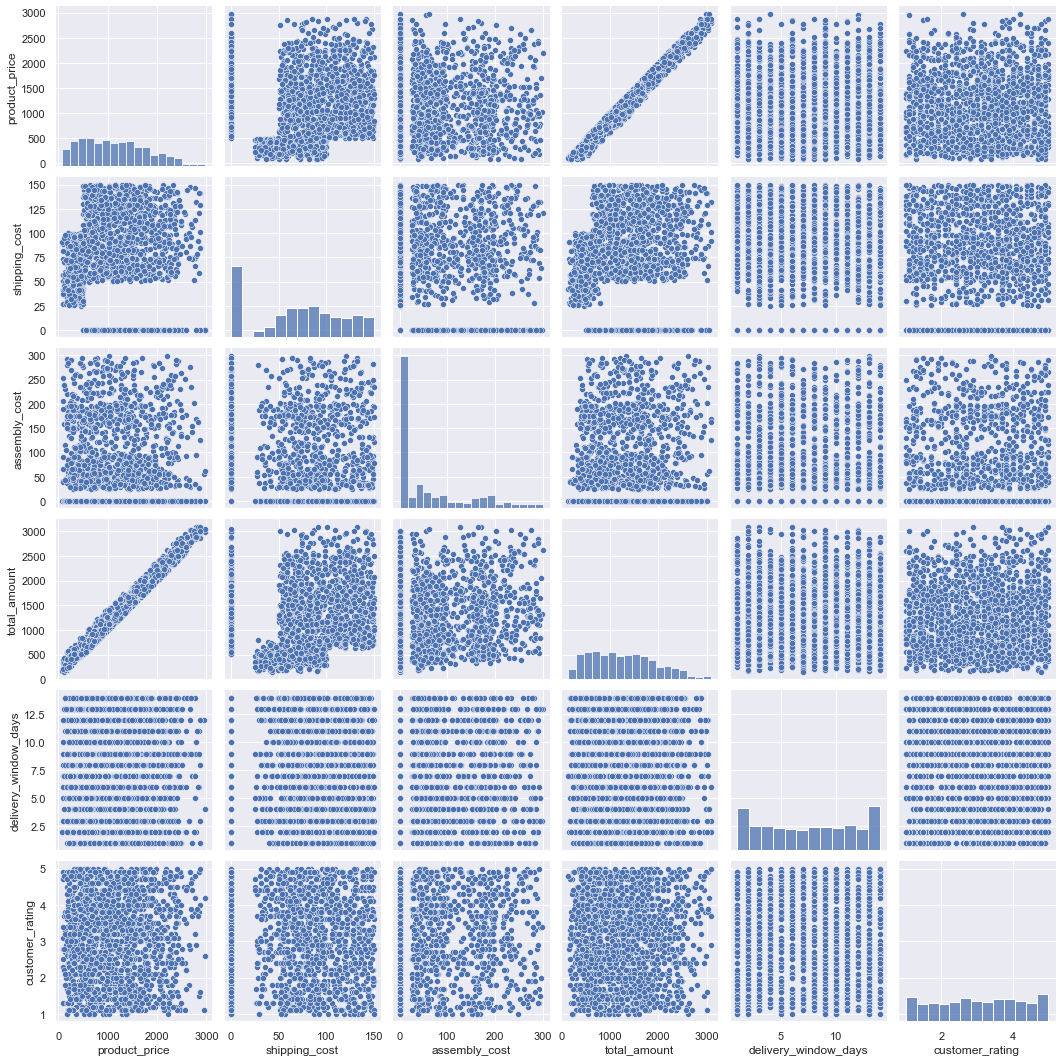

In [42]:
sns.pairplot(df[num_cols]);

We get similar insights from the scatter plots as from the heatmap

In [43]:
df.head() #displaying the first 5 rows in order to recall needed features for further bivariate analysis

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
0,Outdoor,Patio Set,World Market,Failed Delivery,True,Credit Card,93810,2824,191.27000,45.63000,86.82000,323.72000,11,3.20000
1,Living Room,Sofa,West Elm,Cancelled,True,Apple Pay,13278,5506,702.87000,52.65000,183.07000,938.59000,10,4.50000
2,Dining Room,Bar Stool,Ashley Furniture,Delivered,False,Cash on Delivery,42098,4657,395.41000,96.79000,0.00000,492.20000,2,NaN
3,Dining Room,China Cabinet,HomeGoods,Pending,False,Google Pay,28289,2679,602.59000,0.00000,0.00000,602.59000,9,NaN
4,Dining Room,China Cabinet,CB2,Pending,True,Apple Pay,98696,9935,1782.36000,69.23000,41.53000,1893.12000,13,1.30000


#### Relationship between Total Amount and Product Category

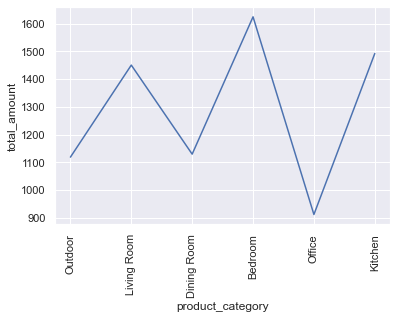

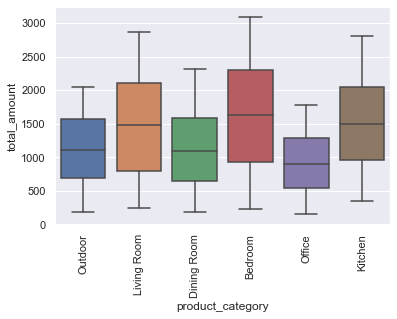

In [44]:
sns.lineplot(data=df, x='product_category', y='total_amount', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_category', y='total_amount');
plt.xticks(rotation=90)
plt.show()

- Office, Outdoor and Dining Room (in that order) have the least average total amount
- Bedroom, Kitchen and Living Room (in that order) have the highest average total amount

#### Relationship between Total Amount and Product Subcategory

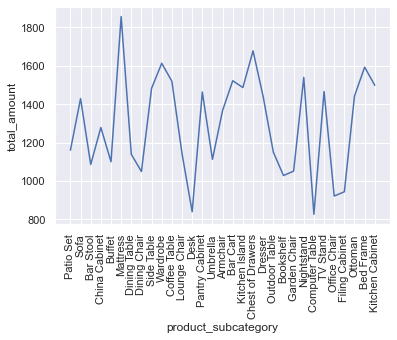

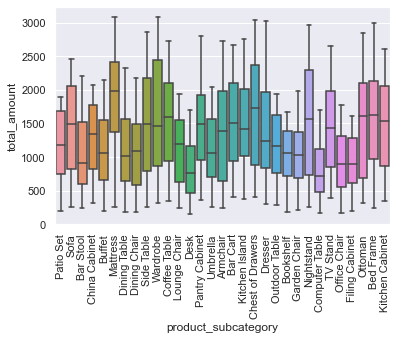

In [45]:
sns.lineplot(data=df, x='product_subcategory', y='total_amount', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_subcategory', y='total_amount');
plt.xticks(rotation=90)
plt.show()

- The bottom 6 expensive products are Computer Table, Desk, Office Chair, Filing Cabinet, Bookshelf and Garden Chair
- The top 6 expensive products are Mattress, Chest of Drawers, Wardrobe, Bedframe, Nightstand and Bart

#### Relationship between Total Amount and Brand

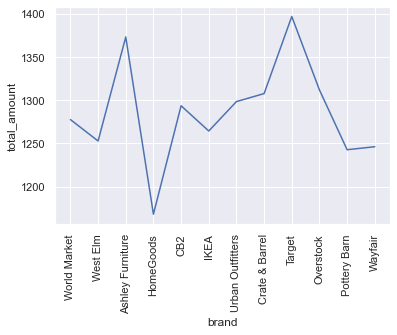

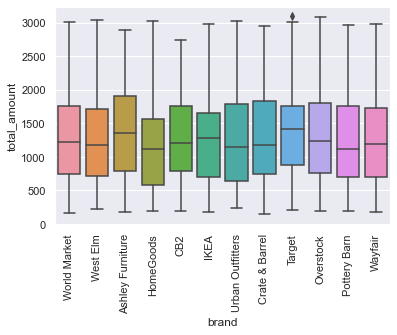

In [46]:
sns.lineplot(data=df, x='brand', y='total_amount', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='brand', y='total_amount');
plt.xticks(rotation=90)
plt.show()

- The 3 least priced brands on average are HomeGoods, Pottery Barn and Wayfair
- The 3 highest priced brands on average are Target, Ashley Furniture and Overstock (in that order)

#### Relationship between Delivery Window Days and Product Category

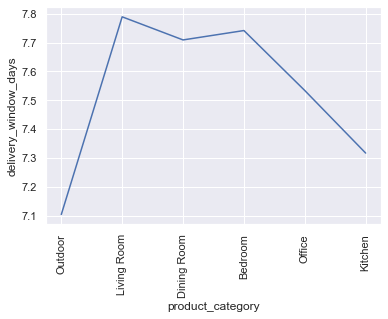

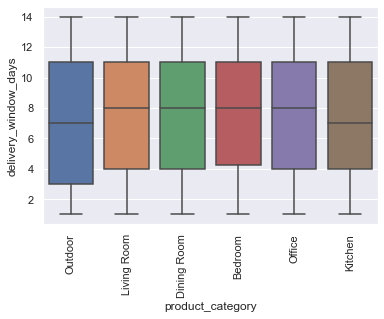

In [47]:
sns.lineplot(data=df, x='product_category', y='delivery_window_days', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_category', y='delivery_window_days');
plt.xticks(rotation=90)
plt.show()

- Outdoor, Kitchen and Office product categories (in that order) have the lowest average delivery window days
- Living Room, Bedroom and Dining Room (in that order) have the highest average delivery window days

#### Relationship between Delivery Window Days and Product Subcategory

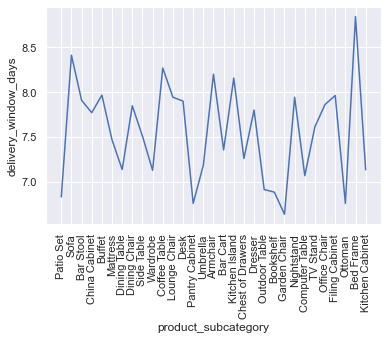

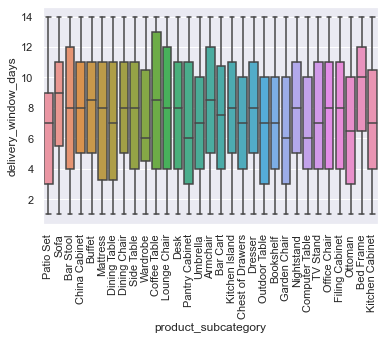

In [48]:
sns.lineplot(data=df, x='product_subcategory', y='delivery_window_days', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_subcategory', y='delivery_window_days');
plt.xticks(rotation=90)
plt.show()

- The 6 Products with the lowest average delivery window days are Garden Chair, Pantry Cabinet, Ottoman, Patio Set, Bookshelf, Outdoor Table (in that order)
- The 6 Products with the highest average delivery window days are Bedframe, Sofa, Coffee Table, Armchair, Kitchen Island and Buffet (in that order)

#### Relationship between Delivery Window Days and Brand

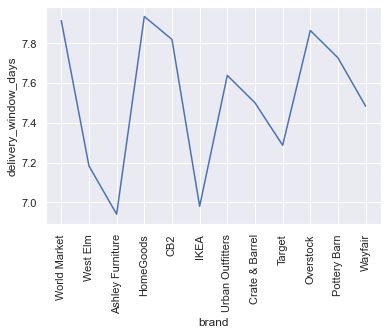

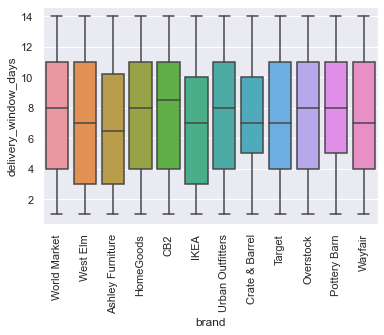

In [49]:
sns.lineplot(data=df, x='brand', y='delivery_window_days', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='brand', y='delivery_window_days');
plt.xticks(rotation=90)
plt.show()

- Ashley Furniture, IKEA and West Elm (in that order) are brands with the least delivery window days
- HomeGoods, World Market, Overstock and CB2 (in that order) are brands with the highest delivery window days

#### Relationship between Customer Rating and Product Category

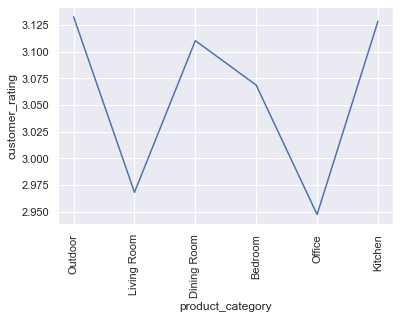

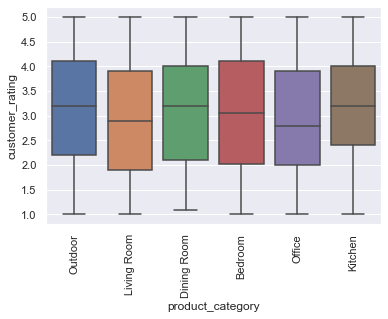

In [50]:
sns.lineplot(data=df, x='product_category', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_category', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- Outdoor has the highest average customer rating, followed by Kitchen and then Dining Room
- Office has the least average rating, followed by Living Room

#### Relationship between Customer Rating and Product Subcategory

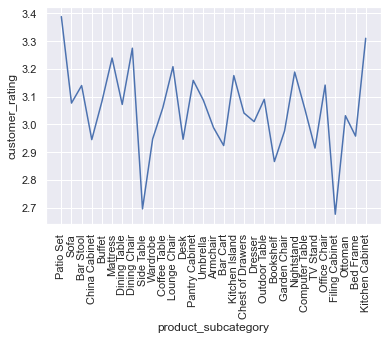

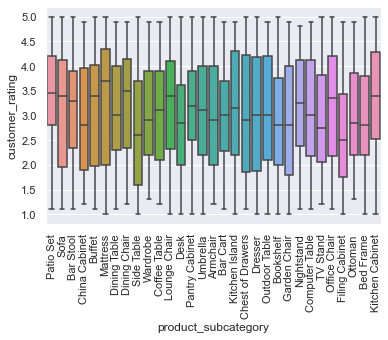

In [51]:
sns.lineplot(data=df, x='product_subcategory', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_subcategory', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- The top 5 rated products are Patio Set, Kitchen Cabinet, Dining Chair, Matress and Lounge Chair
- The bottom 3 rated products are Filing Cabinet, Mattress Side Table and Bookshelf 

#### Relationship between Customer Rating and Brand

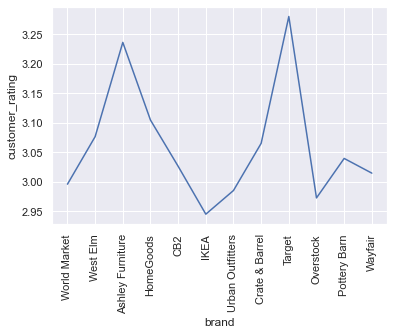

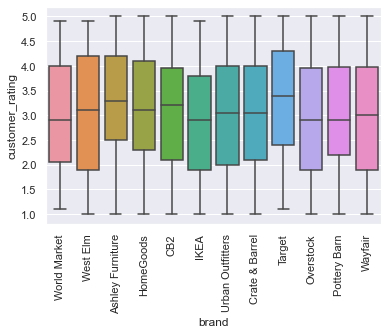

In [52]:
sns.lineplot(data=df, x='brand', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='brand', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- Target then Ashley Furniture have the highest customer ratings
- IKEA then Overstock have the least customer rating

#### Relationship between Customer Rating and Delivery Status

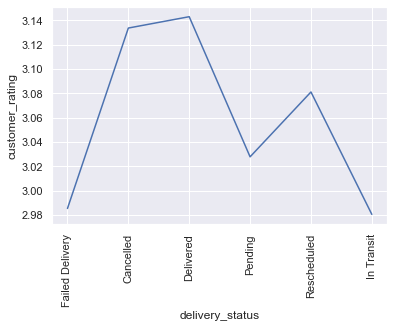

In [53]:
sns.lineplot(data=df, x='delivery_status', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- Customers rated Delivered orders the highest, followed by Cancelled orders
- They rated In Transit orders the least, followed by Failed Delivery

#### Relationship between Customer Rating and Payment Method

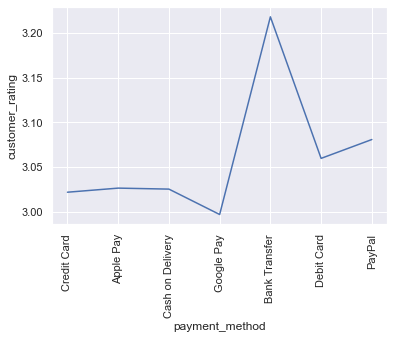

In [54]:
sns.lineplot(data=df, x='payment_method', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- Orders paid for using Bank Transfer were rated highest, followed by PayPal and then Debit Card
- Google Pay payment method was rated the least

#### Relationship between Customer Rating and Assembly_Service_Requested

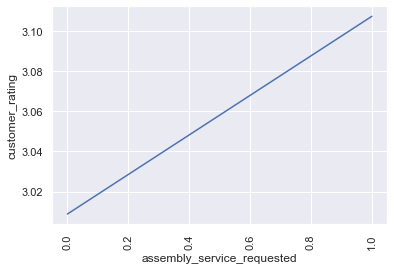

In [55]:
sns.lineplot(data=df, x='assembly_service_requested', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

In [56]:
df.groupby(['assembly_service_requested'])['customer_rating'].mean()

assembly_service_requested
False   3.00887
True    3.10721
Name: customer_rating, dtype: float64

- Orders that included assembly service requests were slightly rated higher on average than those without 

## Missing Value Treatment

Displaying the count and percentage of missing values

In [57]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0])/df.shape[0]*100})

,Count,Percentage
brand,96,4.95356
shipping_cost,58,2.99278
assembly_cost,38,1.96078
customer_rating,280,14.44788


- `customer_rating` has the highest percentage of missing values
- `assembly_cost` has the least percentage of missing values
- `brand` and `shipping_cost` have about 5% and 3% missing values respectively

#### Missing value treatment for Brand

In [58]:
df.loc[df['brand'].isnull()==True]

,product_category,product_subcategory,brand,delivery_status,assembly_service_requested,payment_method,order_id,customer_id,product_price,shipping_cost,assembly_cost,total_amount,delivery_window_days,customer_rating
29,Office,Bookshelf,NaN,Pending,True,Credit Card,96673,4733,142.60000,50.02000,116.16000,308.78000,8,2.70000
65,Living Room,Armchair,NaN,Pending,True,Google Pay,79352,5119,1331.02000,118.65000,90.56000,1540.23000,5,NaN
70,Dining Room,China Cabinet,NaN,Failed Delivery,True,Apple Pay,24621,5808,1523.02000,78.86000,253.30000,1855.18000,12,2.10000
99,Bedroom,Bed Frame,NaN,In Transit,True,Credit Card,42493,4681,2854.68000,59.17000,26.26000,2940.11000,6,1.50000
111,Outdoor,Outdoor Table,NaN,Delivered,True,Apple Pay,27342,8744,1431.78000,58.50000,57.87000,1548.15000,10,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1826,Kitchen,Pantry Cabinet,NaN,Cancelled,False,Cash on Delivery,67438,7875,2135.44000,0.00000,0.00000,2135.44000,10,NaN
1865,Outdoor,Garden Chair,NaN,Rescheduled,False,Bank Transfer,60793,4029,596.07000,119.20000,0.00000,715.27000,2,1.50000
1866,Living Room,TV Stand,NaN,Delivered,True,Bank Transfer,58630,7249,2396.69000,142.22000,90.27000,2629.18000,9,5.00000
1869,Office,Bookshelf,NaN,Cancelled,False,Bank Transfer,44510,8204,959.99000,58.58000,0.00000,1018.57000,1,NaN


- There does not appear to be a pattern in the missingness of data in `brand`
- However, there are data points in `customer_rating` that are also null where `brand` is null. Let's check how many these are

In [59]:
df.loc[df['brand'].isnull()==True, 'customer_rating'].value_counts(dropna=False).head(10)

NaN        18
1.30000     6
3.10000     6
4.30000     5
3.70000     4
3.90000     4
3.20000     3
1.50000     3
4.00000     3
4.10000     3
Name: customer_rating, dtype: int64

- Relative to 96 missing values in `brand`, there are only 18 data points in `customer_rating` that fall into this category.
- Hence, we say there is not really a pattern of missing values with respect to `customer_rating`
- Let's see with respect to the other 2 columns with missing values

In [60]:
df.loc[df['brand'].isnull()==True, 'shipping_cost'].value_counts(dropna=False)

0.00000      19
50.02000      1
65.95000      1
34.95000      1
83.33000      1
             ..
134.28000     1
64.77000      1
119.81000     1
87.32000      1
129.01000     1
Name: shipping_cost, Length: 78, dtype: int64

In [61]:
df.loc[df['brand'].isnull()==True, 'assembly_cost'].value_counts(dropna=False).head(10)

0.00000      36
NaN           3
116.16000     1
258.75000     1
145.17000     1
38.87000      1
175.63000     1
201.63000     1
196.14000     1
163.15000     1
Name: assembly_cost, dtype: int64

There is no pattern in data missingness with respect to `shipping_cost` and `assembly_cost` too

Given that `brand` is a categorical feature, we will now impute the missing values in it with its mode

In [62]:
df['brand'] = df['brand'].fillna(value = df['brand'].mode()[0])

In [63]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0])/df.shape[0]*100})

,Count,Percentage
shipping_cost,58,2.99278
assembly_cost,38,1.96078
customer_rating,280,14.44788


We see that `brand` has been imputed successfully

#### Missing value treatment for Shipping Cost

Firstly, let's plot the distribution of `shipping_cost`

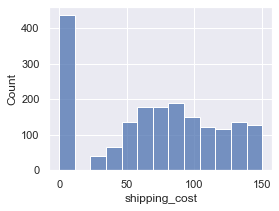

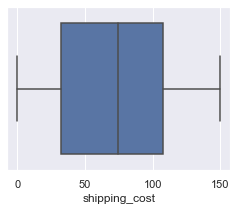

In [64]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='shipping_cost')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='shipping_cost')
plt.show()

- Since there are no outliers, imputation with the mean of the column will be appropriate
- Also, it is more likely that products of a particular category, subcategory and brand would have similar shipping costs. Hence, we will be imputing the nulls in `shipping_cost` based on products in similar categories, subcategories and with similar brands

In [65]:
df['shipping_cost'] = df['shipping_cost'].fillna(value = df.groupby(['product_category','product_subcategory','brand'])['shipping_cost'].transform('mean'))

In [66]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0])/df.shape[0]*100})

,Count,Percentage
assembly_cost,38,1.96078
customer_rating,280,14.44788


Imputation was done successfully

Let's see the distribution of the column after imputation

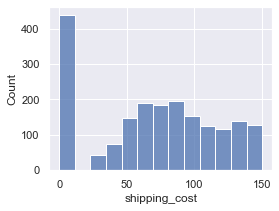

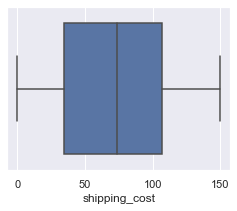

In [67]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='shipping_cost')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='shipping_cost')
plt.show()

After imputation of `shipping_cost`, the distribution is still symmetrical with the original data, which is good

#### Missing value treatment for Assembly Cost

Let's plot the distribution of `assembly_cost`

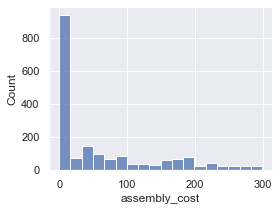

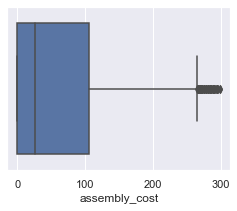

In [68]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='assembly_cost')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='assembly_cost')
plt.show()

- We see that there are lots of outliers in the column, so imputing with the column's median would be more appropriate here
- We will also employ the grouping approach used relative to `shipping_cost`

In [69]:
df['assembly_cost'] = df['assembly_cost'].fillna(value = df.groupby(['product_category','product_subcategory','brand'])['assembly_cost'].transform('median'))

In [70]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0])/df.shape[0]*100})

,Count,Percentage
customer_rating,280,14.44788


`assembly_cost` was imputed successfully

Let's see the distribution of the column after imputation

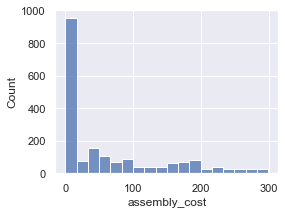

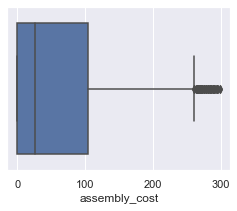

In [71]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='assembly_cost')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='assembly_cost')
plt.show()

After imputation, the distribution is still symmetrical with the original data, which is good

#### Missing value treatment for Customer Rating

Firslty plotting the distribution of the column

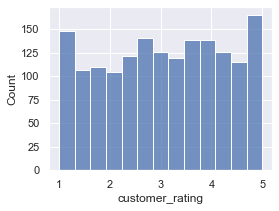

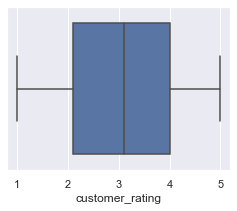

In [72]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='customer_rating')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='customer_rating')
plt.show()

- No outliers present, so we will impute with the mean of the column while employing the grouping method used earlier

In [73]:
df['customer_rating'] = df['customer_rating'].fillna(value = df.groupby(['product_category','product_subcategory','brand'])['customer_rating'].transform('mean'))

In [74]:
pd.DataFrame({'Count': df.isnull().sum()[df.isnull().sum()>0], 'Percentage': (df.isnull().sum()[df.isnull().sum()>0])/df.shape[0]*100})

,Count,Percentage


In [75]:
df.isnull().sum()

product_category              0
product_subcategory           0
brand                         0
delivery_status               0
assembly_service_requested    0
payment_method                0
order_id                      0
customer_id                   0
product_price                 0
shipping_cost                 0
assembly_cost                 0
total_amount                  0
delivery_window_days          0
customer_rating               0
dtype: int64

Imputation was carried successfully and there are no more missing values in the entire dataset

Let's see the distribution of the `customer_rating` after imputation

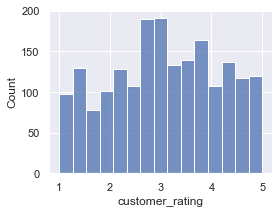

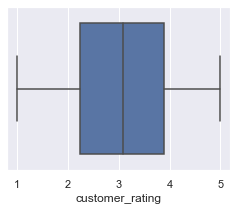

In [76]:
plt.figure(figsize=(4,3))
sns.histplot(df, x='customer_rating')
plt.show()
plt.figure(figsize=(4,3))
sns.boxplot(data=df, x='customer_rating')
plt.show()

After imputation, the distribution is slightly distorted and now only partly symmetrical with the original data. Given this, we should re-conduct previous explorations specific to `customer_rating` and that will be done below

## Repeat of EDA on `customer_rating`

In [77]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
product_price,1938.00000,1155.93003,658.49091,81.43000,609.24250,1076.23000,1628.55000,2979.56000
shipping_cost,1938.00000,69.51960,47.10229,0.00000,34.64000,73.64000,106.60500,150.00000
assembly_cost,1938.00000,62.35434,82.07694,0.00000,0.00000,26.43500,104.07000,299.35000
total_amount,1938.00000,1288.39001,669.22865,146.93000,722.70750,1224.17500,1758.50000,3093.29000
delivery_window_days,1938.00000,7.52838,3.98700,1.00000,4.00000,8.00000,11.00000,14.00000
customer_rating,1938.00000,3.05970,1.08941,1.00000,2.23333,3.08542,3.90000,5.00000


- The mean and median of `customer_rating` are almost identical indicating a possible near-symmetrical distribution
- However, the median is still greater than the mean indicating a possible left-skewed distribution
- Ratings are ranged between 1 and 5
- Overall, findings are still similar to those seen before imputation

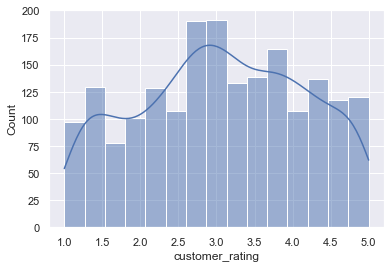

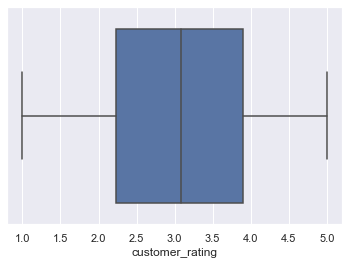

In [78]:
sns.histplot(df, x='customer_rating', kde=True);
plt.show()
sns.boxplot(data=df, x='customer_rating');
plt.show()

- As earlier suspected, distribution of `customer_rating` is near-symmetrical but left-skewed
- Skewness is lesser than before imputation
- 25% of ratings are above about 2.2


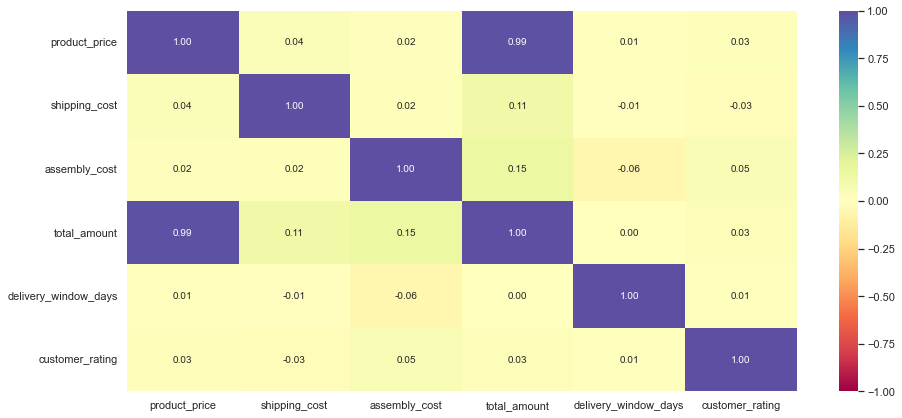

In [79]:
plt.figure(figsize=(15,7))
sns.heatmap(df[num_cols].corr(), annot=True, vmin=-1, vmax=1, fmt='.2f', cmap='Spectral');
plt.show()

- The correlation coefficient of `customer_rating` in relation to other variables is practically 0; same as before imputation
- `customer_rating` has no correlation with other variables

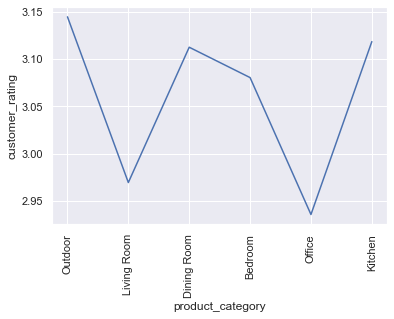

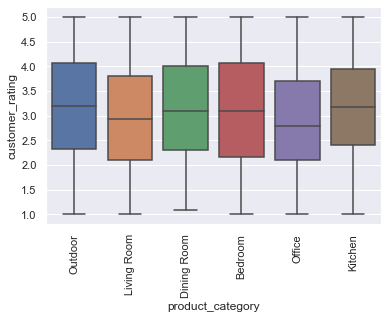

In [80]:
sns.lineplot(data=df, x='product_category', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_category', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- Outdoor has the highest average customer rating, followed by Kitchen and then Dining Room
- Office has the least average rating, followed by Living Room
- Findings still similar to before imputation

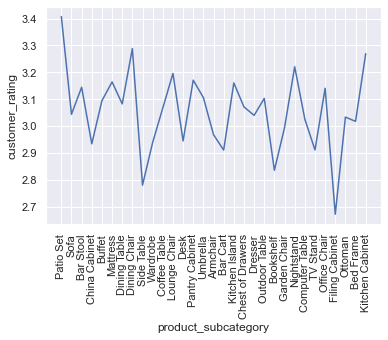

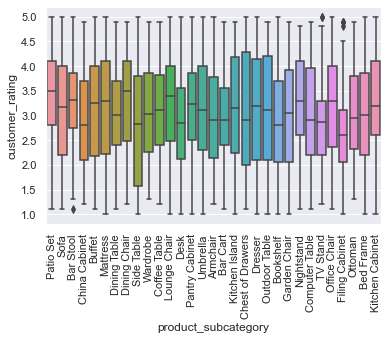

In [81]:
sns.lineplot(data=df, x='product_subcategory', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='product_subcategory', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- There are some differences in findings here after imputation
- The top 5 rated products are now Patio Set, followed by Dining Chair, then Kitchen Cabinet, Nightstand and Lounge Chair
- The bottom 3 rated products are Filing Cabinet, Side Table and Bookshelf 

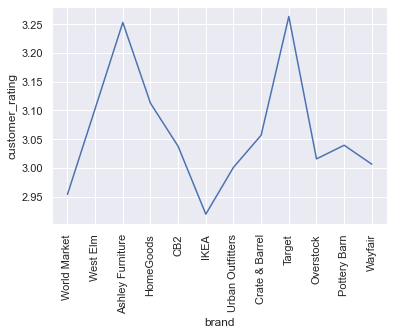

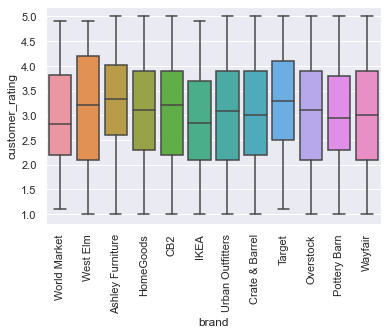

In [82]:
sns.lineplot(data=df, x='brand', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()
sns.boxplot(data=df, x='brand', y='customer_rating');
plt.xticks(rotation=90)
plt.show()

- Slight variation in findings after imputation
- Target then Ashley Furniture have the highest customer ratings
- IKEA then World Market now have the least customer rating

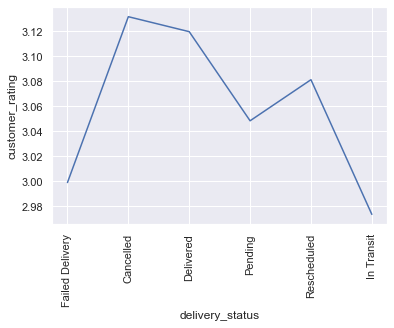

In [83]:
sns.lineplot(data=df, x='delivery_status', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- Slight variation in findings  here too after imputation
- Customers rated Cancelled orders the highest, followed by Delivered orders
- They rated In Transit orders the least, followed by Failed Delivery

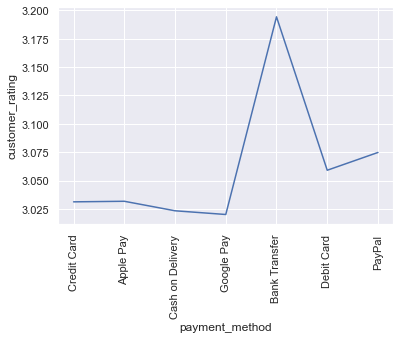

In [84]:
sns.lineplot(data=df, x='payment_method', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- Slight difference in findings after imputation
- Orders paid for using Bank Transfer were rated highest, followed by PayPal and then Debit Card
- Orders placed using Google Pay payment method were rated the least, followed closely by Cash on Delivery

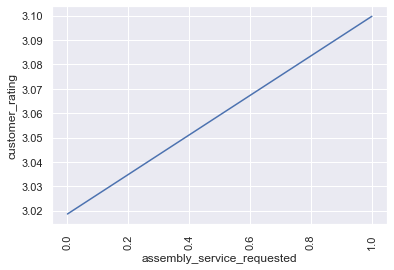

In [85]:
sns.lineplot(data=df, x='assembly_service_requested', y='customer_rating', ci=None);
plt.xticks(rotation=90)
plt.show()

- Orders that included assembly service requests were slightly rated higher on average than those without 

## Actionable Insights and Recommendations

### Insights

We analysed a dataset of about 1900 orders for furniture in a furniture store and their respective relevant information. The data included furniture products varying between 12 brands, divided into 6 product categories and further categorised into 31 different subcategories. The data also included the the payment method used for each order, the order total amount, customer rating for each order, and other attributes. The main variable of interest here is the customer rating achieved by each order.

We wanted to identify the orders with the highest customer rating and which product brands, subcategories and categories constitute such orders, thus, we arrived at the following conclusions:

- Achieving 338 and 333 orders respectively, Outdoor and Living Room are the most popular product categories among customers 
- Dining Room products were ordered the least at 303 orders
- Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet and Office Chair were the most popular product subcategories ordered by customers
- Product subcategories Bar Stool, Wardrobe, Armchair and Chest of Drawers were the least popular among customers
- Brands Overstock, HomeGoods and World Market are the top 3 patronised by customers
- Target, Wayfair and Crate & Barrel were the bottom 3 brands patronised by customised
- About 18% of orders are delivered
- Half of the total orders failed, were cancelled or were rescheduled
- 51% of orders included assembly service requests, while 49% did not
- Bedroom, Kitchen and Living Room products constitute the higest total costs
- Office products cost the least
- Target and Ashley Furniture brands are the most expensive
- HomeGoods, Pottery Barn and Wayfair are the cheapest brands
- Living Room, Bedroom and Dining Room products had the highest delivery window days
- Outdoor products had the least delivery window days
- Outdoor, Kitchen and Dining Room produscts had the highest customer ratings
- Office and Living Room products were rated the least by customers
- Target and Ashley Furniture brands had the highest customer ratings
- IKEA and World Market had the least customer rating
- Cancelled and Delivered orders were rated the highest
- In Transit and Failed Delivery orders were rated the lowest
- Orders paid for using Bank Transfer were rated the highest
- Orders paid for using Google Pay were rated the least

### Recommendations

- The store should prioritise inventory and marketing expansion for high-demand categories such as Outdoor and Living Room, while reassessing product mix and promotion strategies for lower-demand categories like Dining Room

- The store should invest more in top-performing subcategories (e.g., Bar Cart, Pantry Cabinet, Garden Chair, Kitchen Cabinet, Office Chair) and consider repositioning or phasing out consistently low-performing subcategories like Bar Stool, Wardrobe, Armchair etc

- The store should strengthen partnerships with highly patronised brands, while reviewing pricing, quality, or branding strategies for underperforming brands to improve customer uptake

- The store should investigate the high rate of failed, cancelled, and rescheduled orders, and improve logistics, communication, and order fulfilment processes to enhance customer experience and reliability

- The store should optimise delivery operations by reducing delivery window days for categories with long wait times, leveraging practices observed in Outdoor products with shorter delivery windows

- The store should focus quality improvement efforts on Office and Living Room products, as these categories received the lowest customer ratings despite relatively high demand

- The store should improve customer satisfaction during transit by addressing issues related to In Transit and Failed Delivery orders, such as real-time tracking etc

- The store should promote and incentivise payment methods associated with higher customer rating, while reviewing and optimising the checkout experience for lower-rated payment options

- The store should use customer rating insights as a key decision-making metric to guide product assortment, brand partnerships, pricing strategies, and operational improvements across the business